In [1]:
import pandas as pd
import numpy as np
import os
import torch
import pytz

from datetime import datetime

from darts import TimeSeries
from darts.models import RNNModel

from darts.metrics import mape
from darts.dataprocessing.transformers import Scaler
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
from sqlalchemy.exc import SQLAlchemyError

from dotenv import load_dotenv

# Load environment variables
load_dotenv(dotenv_path='../src/.env')

DB_SECRET = os.getenv('DB_SECRET')
DB_HOSTNAME = os.getenv('DB_HOSTNAME')
DB_PORT = int(os.getenv('DB_PORT'))
DB_NAME = os.getenv('DB_NAME')
DB_USER = os.getenv('DB_USER')


/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


In [2]:
def device_check():
    if torch.backends.mps.is_available():
        return torch.device("mps"), True
    elif torch.cuda.is_available():
        return torch.device("cuda"), False
    else:
        return torch.device("cpu"), False

device, force_float32 = device_check()
device, force_float32


(device(type='mps'), True)

In [3]:
def load_data(metric_name):
    engine = create_engine(
        f'postgresql+psycopg2://{DB_USER}:{DB_SECRET}@{DB_HOSTNAME}:{DB_PORT}/{DB_NAME}'
    )
    query = text(f"SELECT * FROM input WHERE metric_name = '{metric_name}'")

    with engine.connect() as conn:
        df = pd.read_sql(query, conn)

    print(f"Loaded {len(df)} records.")
    return df

metric_name = "cpu_usage_upf"
df_raw = load_data(metric_name)
df_raw.head()


Loaded 14264 records.


,metric_name,value,datetime
0,cpu_usage_upf,0.000093,2025-11-19 00:01:15+00:00
1,cpu_usage_upf,0.000120,2025-11-19 00:01:30+00:00
2,cpu_usage_upf,0.000128,2025-11-19 00:01:45+00:00
3,cpu_usage_upf,0.000141,2025-11-19 00:02:00+00:00
4,cpu_usage_upf,0.000162,2025-11-19 02:52:15+00:00


In [4]:
def data_transformation(df, frequency):
    df_pivot = df.pivot_table(
        index='datetime', 
        columns='metric_name', 
        values='value'
    )

    df_resampled = (
        df_pivot
        .reset_index()
        .resample(frequency, on="datetime")
        .max()
        .interpolate()
    )

    df_resampled.index = df_resampled.index.tz_localize(None)
    return df_resampled

frequency = "5T"
df_resampled = data_transformation(df_raw, frequency)
df_resampled.head()


/var/folders/vr/sg92rdxs1cq_7f1s1jhpw2dh0000gn/T/ipykernel_75599/233506236.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .resample(frequency, on="datetime")


metric_name,cpu_usage_upf
datetime,
2025-11-19 00:00:00,0.000150
2025-11-19 00:05:00,0.000134
2025-11-19 00:10:00,0.000128
2025-11-19 00:15:00,0.000143
2025-11-19 00:20:00,0.000172


In [5]:
def split_dataset(df):
    train_size = int(0.7 * len(df))
    split_point = df.iloc[train_size].name

    series = TimeSeries.from_dataframe(df.reset_index(), "datetime")

    train, test = series.split_after(split_point)
    print(f"Train: {len(train)}, Test: {len(test)}")
    return series, train, test

series, train, test = split_dataset(df_resampled)


Train: 526, Test: 224


In [53]:
from sklearn.preprocessing import StandardScaler

def normalize_series(series, train, test):
    scaler = Scaler(StandardScaler())

    train_t = scaler.fit_transform(train)
    test_t = scaler.transform(test)
    series_t = scaler.transform(series)

    return series_t, train_t, test_t, scaler

series_t, train_t, test_t, transformer = normalize_series(series, train, test)


In [61]:
def train_lstm(model_name, train_t, test_t, force_float32):

    if force_float32:
        train_t = train_t.astype(np.float32)
        test_t = test_t.astype(np.float32)

    stopper = EarlyStopping(
        monitor="val_loss",
        patience=10,
        min_delta=0.0005,
        mode="min",
    )

    model = RNNModel(
        model="LSTM",
        hidden_dim=50,
        dropout=0.1,
        batch_size=8,
        n_epochs=100,
        optimizer_kwargs={"lr": 1e-3},
        model_name=model_name,
        log_tensorboard=True,
        random_state=42,
        training_length=48,
        input_chunk_length=12,
        output_chunk_length=1,
        force_reset=True,
        save_checkpoints=True,
        pl_trainer_kwargs={"callbacks": [stopper]},
    )

    model.fit(train_t, val_series=test_t, verbose=True)

    return model


# ---- Run training ----
model_name = "LSTM_cpu_usage_prometheus_local"
my_model = train_lstm(model_name, train_t, test_t, force_float32)


ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.
/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 10.6 K | train
6 | V               | Linear           | 51     | t

Sanity Checking: |                                                                                            …

/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

In [62]:
def evaluate(model, series_t, test_t):
    test_size = len(test_t)
    pred = model.predict(n=test_size - 1)
    score = mape(pred, test_t)
    print(f"MAPE: {score}")
    return score

mape_score = evaluate(my_model, series_t, test_t)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                                 …

MAPE: 225.28234485954815


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/AlicePiemonti/miniconda

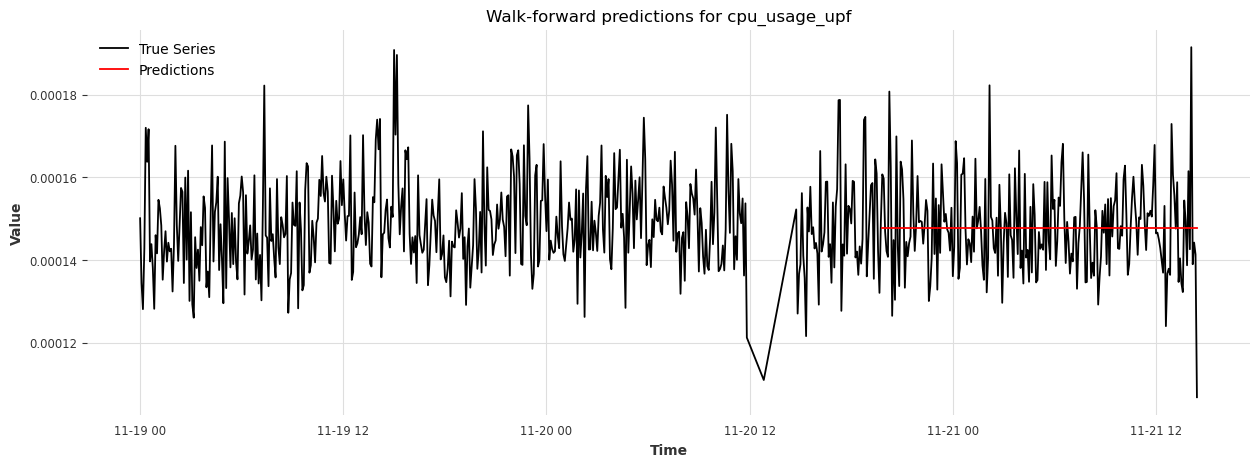

In [63]:
import matplotlib.pyplot as plt

# Choose how many steps you want to predict
# Assuming 5min interval, 1 day = 24*12 = 288 steps
n_steps = 288  

# Full series as TimeSeries
full_series = series  # original, unnormalized

# Walk-forward predictions
preds = []
history = full_series[:len(train_t)]  # start with training portion

for i in range(len(train_t), len(full_series)):
    # predict 1 step ahead
    pred = my_model.predict(n=1, verbose=False)
    # inverse transform
    pred_inv = transformer.inverse_transform(pred)
    preds.append(pred_inv.values()[0][0])  # extract scalar
    # append real value to history for next step
    history = history.append(full_series[i:i+1])

# Prepare time index for predicted values
pred_index = full_series[len(train_t):len(train_t)+len(preds)].time_index

# Plot
plt.figure(figsize=(15,5))
plt.plot(full_series.time_index, full_series.values(), label="True Series")
plt.plot(pred_index, preds, label="Predictions", color='red')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title(f"Walk-forward predictions for {metric_name}")
plt.legend()
plt.show()
